In [3]:
import pandas as pd
from scipy.io import arff

path = r"C:\Users\bipla\Downloads\phishing+websites\Training Dataset.arff"

data, meta = arff.loadarff(path)

df = pd.DataFrame(data)

# convert bytes to int
df = df.applymap(lambda x: int(x) if isinstance(x, bytes) else x)

df.head()

C:\Users\bipla\AppData\Local\Temp\ipykernel_6220\4199533361.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: int(x) if isinstance(x, bytes) else x)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Result'].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

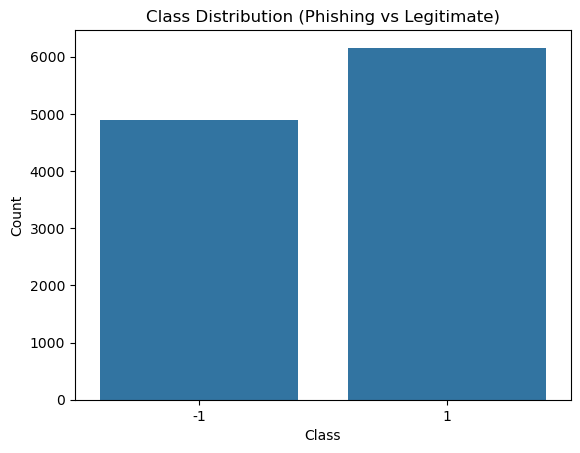

In [5]:
sns.countplot(x='Result', data=df)
plt.title("Class Distribution (Phishing vs Legitimate)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The class distribution shows that the dataset contains 6157 legitimate websites and 4898 phishing websites.
Although slightly imbalanced, the dataset is suitable for training machine learning models.

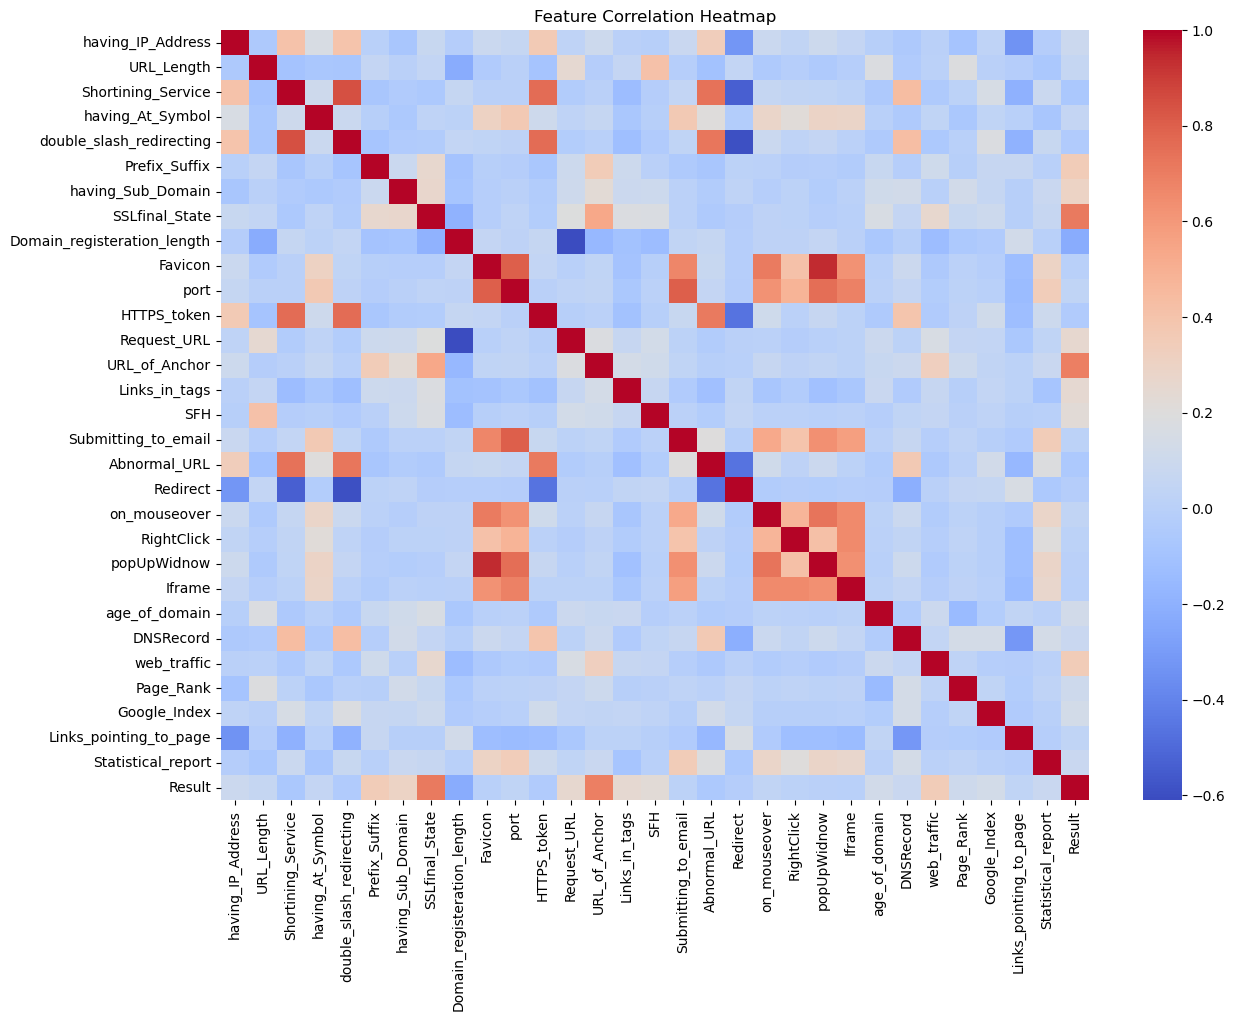

In [6]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

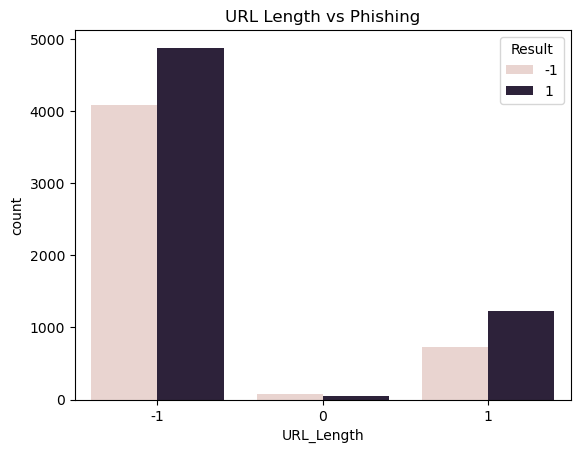

In [7]:
sns.countplot(x='URL_Length', hue='Result', data=df)
plt.title("URL Length vs Phishing")
plt.show()

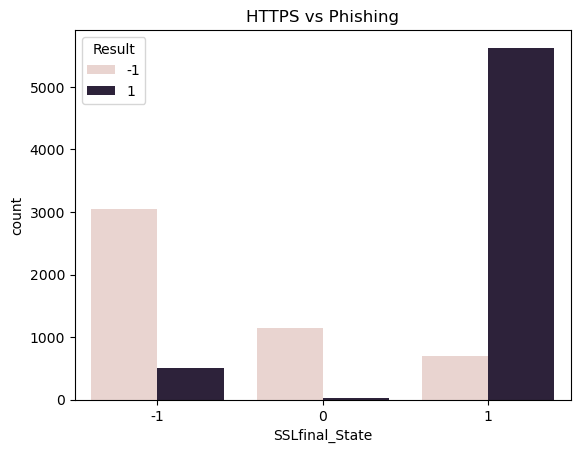

In [8]:
sns.countplot(x='SSLfinal_State', hue='Result', data=df)
plt.title("HTTPS vs Phishing")
plt.show()

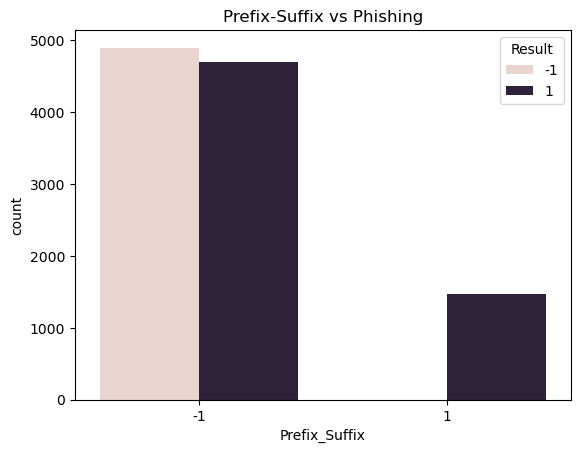

In [9]:
sns.countplot(x='Prefix_Suffix', hue='Result', data=df)
plt.title("Prefix-Suffix vs Phishing")
plt.show()

Long URLs are more common in phishing websites.
Websites without HTTPS are more likely to be phishing.
The presence of prefix/suffix (“-”) in domain names is a strong indicator of phishing.

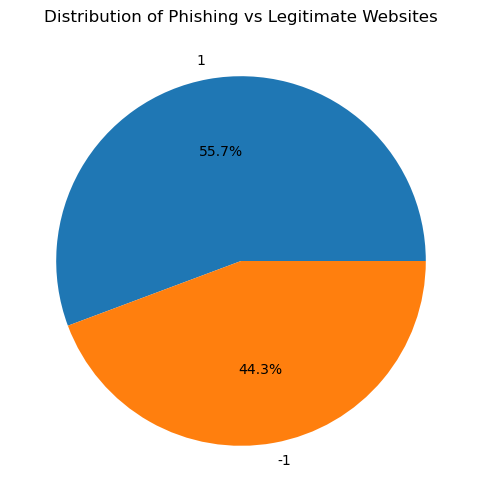

In [10]:
df['Result'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Distribution of Phishing vs Legitimate Websites"
)

plt.ylabel("")
plt.show()

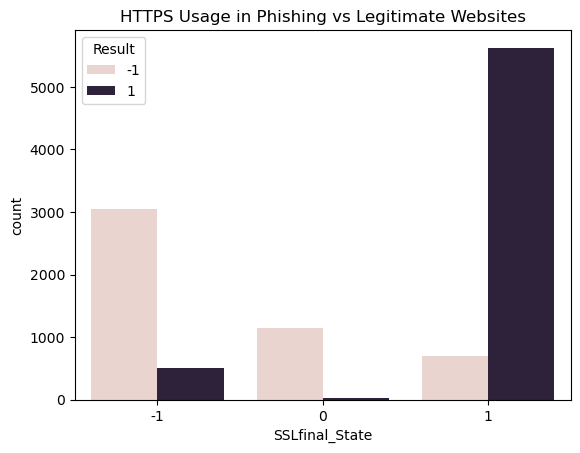

In [11]:
sns.countplot(x='SSLfinal_State', hue='Result', data=df)

plt.title("HTTPS Usage in Phishing vs Legitimate Websites")

plt.show()

In [12]:
df['Result'] = df['Result'].replace(-1,0)

In [13]:
df.isnull().sum()

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [14]:
df.fillna(df.median(), inplace=True)

In [15]:
X = df.drop('Result', axis=1)
y = df['Result']

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [17]:
splits = [0.3, 0.2, 0.4]  # 70:30, 80:20, 60:40

results = {}

for test_size in splits:
    
    split_name = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    print("\n===== Split:", split_name, "=====")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )
    
    # Scaling (only for some models)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results[split_name] = {}
    
    # 1️⃣ Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train_scaled, y_train)
    acc_lr = accuracy_score(y_test, lr.predict(X_test_scaled))
    results[split_name]['LR'] = acc_lr
    
    # 2️⃣ SVM
    svm = SVC()
    svm.fit(X_train_scaled, y_train)
    acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
    results[split_name]['SVM'] = acc_svm
    
    # 3️⃣ KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_scaled, y_train)
    acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
    results[split_name]['KNN'] = acc_knn
    
    # 4️⃣ Decision Tree
    dt = DecisionTreeClassifier()
    dt.fit(X_train, y_train)
    acc_dt = accuracy_score(y_test, dt.predict(X_test))
    results[split_name]['DT'] = acc_dt
    
    # 5️⃣ Random Forest
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    acc_rf = accuracy_score(y_test, rf.predict(X_test))
    results[split_name]['RF'] = acc_rf
    
    # 6️⃣ Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train_scaled, y_train)
    acc_nb = accuracy_score(y_test, nb.predict(X_test_scaled))
    results[split_name]['NB'] = acc_nb
    
    # Print results
    for model, acc in results[split_name].items():
        print(model, ":", round(acc,4))


===== Split: 70:30 =====
LR : 0.9219
SVM : 0.9466
KNN : 0.9337
DT : 0.956
RF : 0.968
NB : 0.5837

===== Split: 80:20 =====
LR : 0.9245
SVM : 0.9525
KNN : 0.9426
DT : 0.9584
RF : 0.9661
NB : 0.5776

===== Split: 60:40 =====
LR : 0.9227
SVM : 0.9473
KNN : 0.9317
DT : 0.9534
RF : 0.9665
NB : 0.5844


In [18]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df

,LR,SVM,KNN,DT,RF,NB
70:30,0.921917,0.946639,0.933675,0.955984,0.968043,0.583660
80:20,0.924469,0.952510,0.942560,0.958390,0.966079,0.577567
60:40,0.922659,0.947309,0.931705,0.953415,0.966531,0.584351


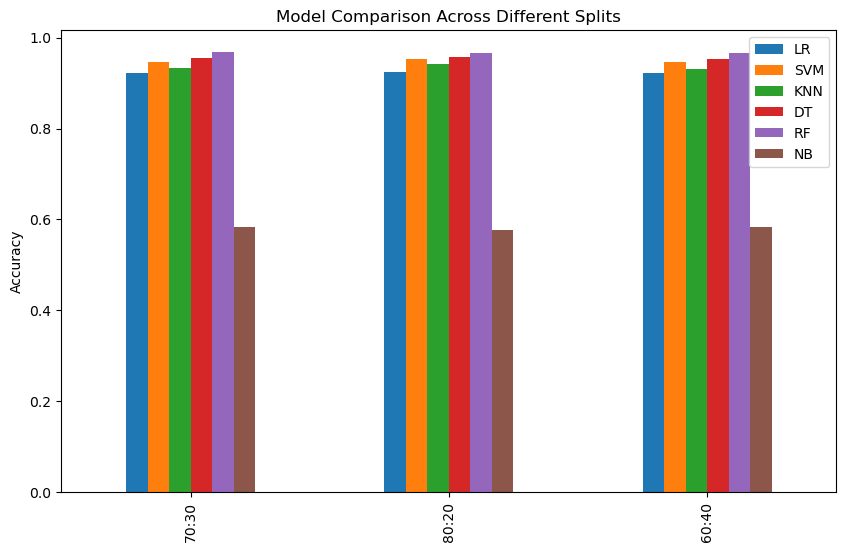

In [19]:
results_df.plot(kind='bar', figsize=(10,6))

plt.title("Model Comparison Across Different Splits")
plt.ylabel("Accuracy")

plt.show()

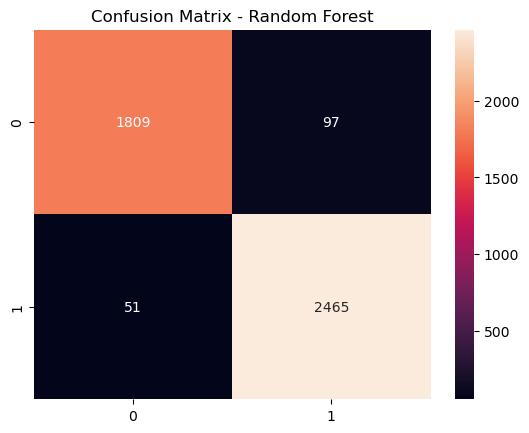

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")
plt.show()

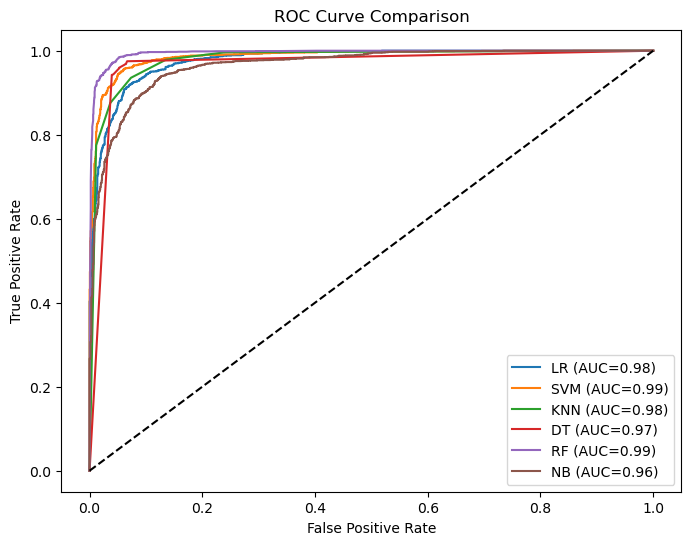

In [21]:
from sklearn.metrics import roc_curve, auc

models = {
    "LR": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(),
    "RF": RandomForestClassifier(),
    "NB": GaussianNB()
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # Scale only where needed
    if name in ["LR", "SVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1], [0,1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

print("===== Cross Validation (5-Fold) =====")

cv_results = {}

models = {
    "LR": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(),
    "RF": RandomForestClassifier(),
    "NB": GaussianNB()
}

for name, model in models.items():
    
    # Scaling needed for some models
    if name in ["LR", "SVM", "KNN"]:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)

    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

    cv_results[name] = scores.mean()
    


===== Cross Validation (5-Fold) =====
LR: Mean=0.9300, Std=0.0034
SVM: Mean=0.9493, Std=0.0022
KNN: Mean=0.9332, Std=0.0026
DT: Mean=0.9554, Std=0.0034
RF: Mean=0.9674, Std=0.0015
NB: Mean=0.6089, Std=0.0062


In [23]:
cv_df = pd.DataFrame(list(cv_results.items()), columns=["Model", "CV Accuracy"])
cv_df

,Model,CV Accuracy
0,LR,0.930047
1,SVM,0.949344
2,KNN,0.933212
3,DT,0.955374
4,RF,0.967435
5,NB,0.608924


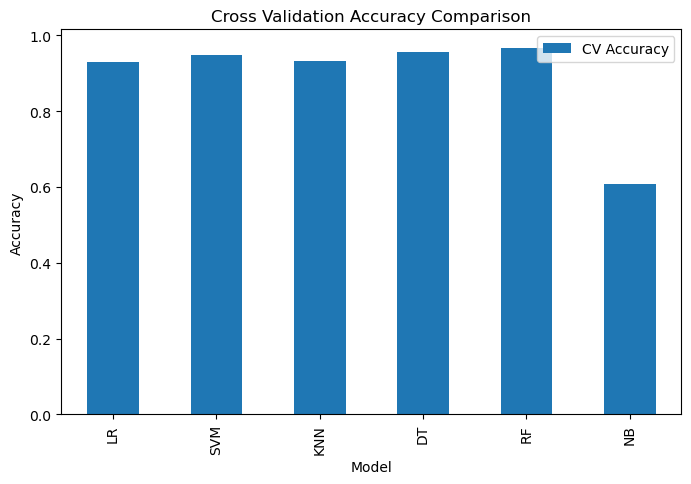

In [24]:
cv_df.set_index("Model").plot(kind='bar', figsize=(8,5))
plt.title("Cross Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Spider Plot Analysis (Feature Comparison)

In [25]:
features = ['URL_Length', 'SSLfinal_State', 'Prefix_Suffix']

# Normalize values from (-1,0,1) → (0,0.5,1)
df_scaled = df.copy()
df_scaled[features] = (df_scaled[features] + 1) / 2

phishing = df_scaled[df_scaled['Result'] == 0][features].mean()
legit = df_scaled[df_scaled['Result'] == 1][features].mean()

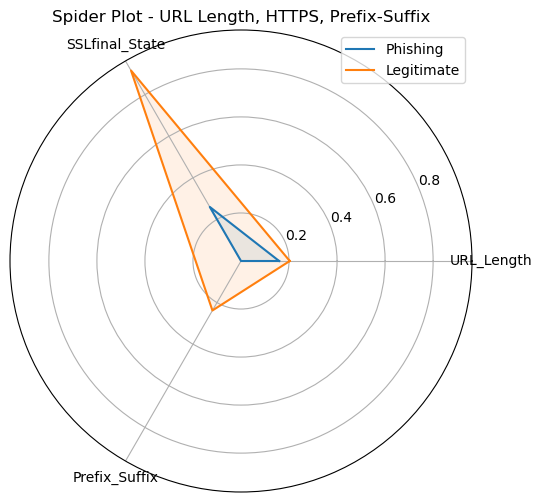

In [26]:
import numpy as np
import matplotlib.pyplot as plt

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()

phishing_values = phishing.tolist()
legit_values = legit.tolist()

phishing_values += phishing_values[:1]
legit_values += legit_values[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))

plt.polar(angles, phishing_values, label='Phishing')
plt.polar(angles, legit_values, label='Legitimate')

plt.fill(angles, phishing_values, alpha=0.1)
plt.fill(angles, legit_values, alpha=0.1)

plt.xticks(angles[:-1], labels)

plt.title("Spider Plot - URL Length, HTTPS, Prefix-Suffix")
plt.legend()

plt.show()

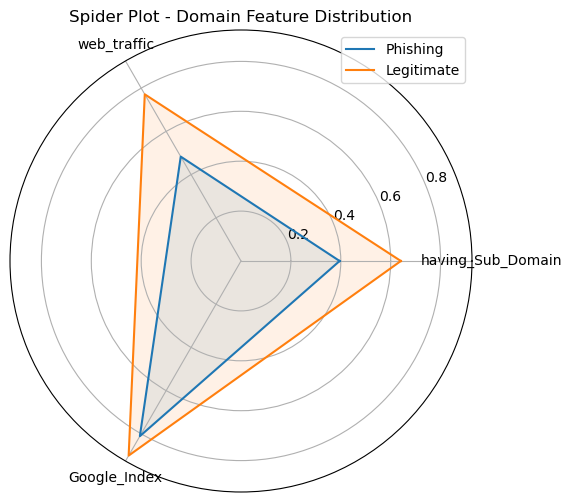

In [27]:
features = ['having_Sub_Domain', 'web_traffic', 'Google_Index']

df_scaled = df.copy()
df_scaled[features] = (df_scaled[features] + 1) / 2

phishing = df_scaled[df_scaled['Result'] == 0][features].mean()
legit = df_scaled[df_scaled['Result'] == 1][features].mean()

import numpy as np
import matplotlib.pyplot as plt

labels = features
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

phishing_values = phishing.tolist()
legit_values = legit.tolist()

phishing_values += phishing_values[:1]
legit_values += legit_values[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))

plt.polar(angles, phishing_values, label='Phishing')
plt.polar(angles, legit_values, label='Legitimate')

plt.fill(angles, phishing_values, alpha=0.1)
plt.fill(angles, legit_values, alpha=0.1)

plt.xticks(angles[:-1], labels)

plt.title("Spider Plot - Domain Feature Distribution")
plt.legend()

plt.show()

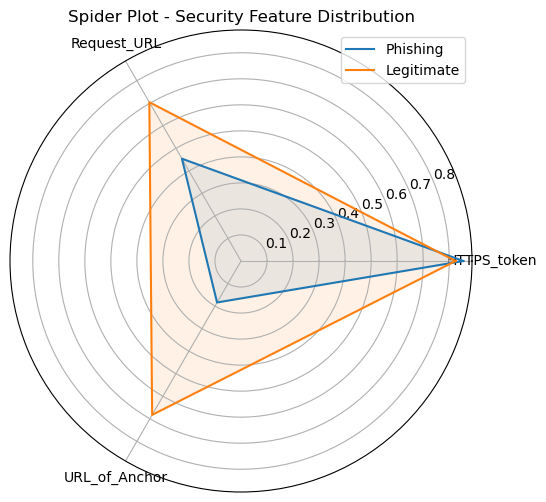

In [28]:
features = ['HTTPS_token', 'Request_URL', 'URL_of_Anchor']

df_scaled = df.copy()
df_scaled[features] = (df_scaled[features] + 1) / 2

phishing = df_scaled[df_scaled['Result'] == 0][features].mean()
legit = df_scaled[df_scaled['Result'] == 1][features].mean()

labels = features
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()

phishing_values = phishing.tolist()
legit_values = legit.tolist()

phishing_values += phishing_values[:1]
legit_values += legit_values[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))

plt.polar(angles, phishing_values, label='Phishing')
plt.polar(angles, legit_values, label='Legitimate')

plt.fill(angles, phishing_values, alpha=0.1)
plt.fill(angles, legit_values, alpha=0.1)

plt.xticks(angles[:-1], labels)

plt.title("Spider Plot - Security Feature Distribution")
plt.legend()

plt.show()

In [29]:
results_df

,LR,SVM,KNN,DT,RF,NB
70:30,0.921917,0.946639,0.933675,0.955984,0.968043,0.583660
80:20,0.924469,0.952510,0.942560,0.958390,0.966079,0.577567
60:40,0.922659,0.947309,0.931705,0.953415,0.966531,0.584351


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1906
           1       0.96      0.98      0.97      2516

    accuracy                           0.97      4422
   macro avg       0.97      0.96      0.97      4422
weighted avg       0.97      0.97      0.97      4422



Random Forest achieved the highest accuracy and showed consistent performance across different data splits. The ROC curve indicates excellent classification capability, making it the most suitable model for phishing detection.

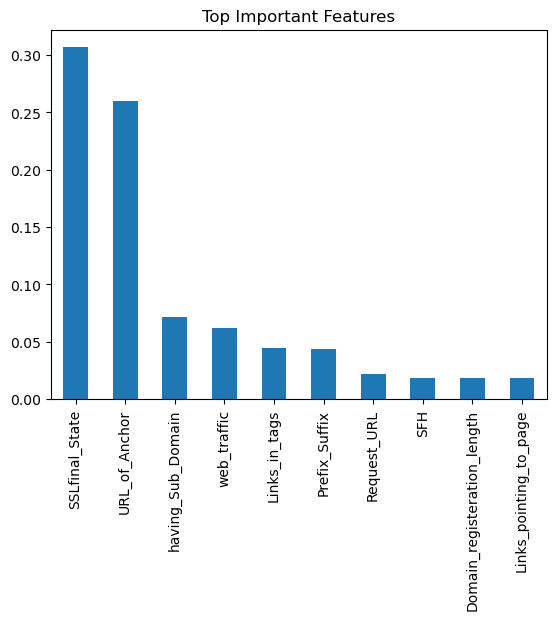

In [31]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Important Features")

plt.show()

In [32]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

AUC Score: 0.9649820373116775


In [33]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X.shape[1],)))   # 👈 better way

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [39]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8664 - loss: 0.3609 - val_accuracy: 0.9201 - val_loss: 0.2186
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9288 - loss: 0.1914 - val_accuracy: 0.9359 - val_loss: 0.1778
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9374 - loss: 0.1672 - val_accuracy: 0.9412 - val_loss: 0.1627
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9414 - loss: 0.1561 - val_accuracy: 0.9412 - val_loss: 0.1541
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9452 - loss: 0.1471 - val_accuracy: 0.9450 - val_loss: 0.1471
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9470 - loss: 0.1399 - val_accuracy: 0.9397 - val_loss: 0.1464
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9476 - loss: 0.1338 - val_accuracy: 0.9435 - val_loss: 0.1415
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9502 - loss: 0.1281 - val_accuracy: 0.

In [40]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

acc = accuracy_score(y_test, y_pred)
print("ANN Accuracy:", acc)

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
ANN Accuracy: 0.9344188150158299


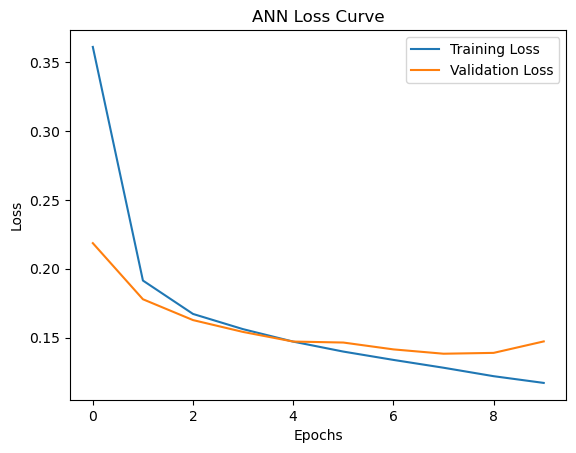

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("ANN Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

This project presents a machine learning and deep learning–based approach for phishing website detection using URL and domain-based features. Multiple classification algorithms, including Logistic Regression, SVM, KNN, Decision Tree, Random Forest, Naive Bayes, and an Artificial Neural Network (ANN), were evaluated across different train-test splits (70:30, 80:20, 60:40) and using cross-validation.

Among all models, Random Forest consistently achieved the highest accuracy (~96–97%) and demonstrated stable performance across different evaluations, making it the most suitable model for this dataset. The ROC curve analysis further confirmed its excellent classification capability. Feature importance analysis revealed that URL length, SSL state, and domain-related characteristics are key indicators of phishing websites.

The ANN model achieved a slightly lower accuracy (~93–94%), which is expected since neural networks typically require larger and more complex datasets to outperform traditional machine learning models. However, ANN demonstrated good learning capability and generalization, as shown by its stable loss curve without significant overfitting.

Overall, the results highlight that while deep learning models are powerful and scalable, traditional ensemble methods like Random Forest are more effective for structured tabular data. This study confirms that machine learning techniques can be highly effective in detecting phishing websites and can be extended for real-world cybersecurity applications.


In [3]:
# Save the deployment artifacts used by app.py
from pathlib import Path
import joblib
from sklearn.ensemble import RandomForestClassifier

# Build the training matrix here so this cell does not rely on X/y from an earlier cell.
if 'df' not in globals():
    import pandas as pd
    from scipy.io import arff

    dataset_path = r'C:\Users\bipla\Downloads\phishing+websites\Training Dataset.arff'
    data, _ = arff.loadarff(dataset_path)
    df = pd.DataFrame(data)
    df = df.applymap(lambda value: int(value) if isinstance(value, bytes) else value)

training_df = df.copy()
training_df['Result'] = training_df['Result'].replace(-1, 0)
training_df = training_df.fillna(training_df.median(numeric_only=True))
X = training_df.drop(columns=['Result'])
y = training_df['Result']

# Train on the complete feature matrix. Result is 0 (phishing) or 1 (legitimate).
phishing_rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
phishing_rf_model.fit(X, y)

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)
joblib.dump(phishing_rf_model, models_dir / 'phishing_rf_model.joblib')
joblib.dump(X.columns.tolist(), models_dir / 'feature_columns.joblib')
print('Saved model and feature order to', models_dir.resolve())


C:\Users\bipla\AppData\Local\Temp\ipykernel_28896\489138585.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda value: int(value) if isinstance(value, bytes) else value)


Saved model and feature order to C:\Users\bipla\OneDrive\Desktop\Phishing\models
